# 01. Simulator và kiểm định

Chương này trả lời câu hỏi: **vì sao tin được con số do simulator sinh ra.** Nội dung:

1. Mô hình thị trường: cầu, cung, ghép xe, bỏ chờ và hủy.
2. Đường throughput và wild goose chase (A1, gate P2/P3).
3. Hiệu chỉnh (CAL, gate P3).
4. Bốn kiểm thử nghiệm thu còn lại: CRN (A2), dao động của π_θ (A3), tính đơn điệu (A4), thời gian chạy (A5).
5. Các bộ dữ liệu giao cho phân tích (B7a, B7b).

Chủ notebook: Tình (T6.1, quyết định H-27). Mọi phép tính nằm trong `analysis/` (chủ yếu `analysis/validation.py`, có test ở `tests/test_validation.py`); notebook chỉ gọi hàm và trình bày. Tiêu chí đạt lấy từ `docs/tests.md` §3–4.

**Dữ liệu cần** (`runs/` không commit; lệnh sinh lại ở `docs/datasets.md`, mục S5 và S6):

| Thư mục | Dùng cho |
|---|---|
| `runs/s6/throughput` | A1: `--mode throughput_curve` |
| `runs/s6/gte_full_5` | CAL: `--mode gte --set gte.n_seeds=5 --log-level full` (log đầy đủ của all_off) |
| `runs/s5/policy_table`, `runs/b7b_h21/sweep_theta_ref` | A2 (b): all_on có B và π_θ θ = 0,3, cùng 30 seed |
| `runs/s6/a3_h0`, `runs/s6/a3_h01` | A3: π_θ θ = 0,35, 5 seed, h = 0 và h = 0,1 |
| `runs/b7a/switchback_c7_28d` | A4 |
| `runs/s6/a5_evaluate_1proc` | A5: `--mode evaluate`, 3 seed, 1 tiến trình |
| `runs/b7a/*`, `runs/b7b_h21/*` | mô tả bộ dữ liệu |

In [1]:
from analysis.notebook import require_runs, setup
from analysis.plots import save_figure

plt = setup()   # repository root, shared plot style, wide pandas display
B7A = ["calibrate_budget", "gte", "legacy_28d", "rider_ab_28d", "switchback_c1_28d", "switchback_c7_28d",
       "switchback_all_28d"]
B7B = ["sweep_theta_ref", "sens_fraction_0p1", "sens_fraction_0p6", "sens_voucher_0p3", "sens_demand_1p5"]
(throughput_dir, gte_full_dir, table_dir, sweep_ref_dir, a3_h0_dir, a3_h01_dir, a5_dir, *dataset_dirs) = require_runs(
    "runs/s6/throughput", "runs/s6/gte_full_5", "runs/s5/policy_table", "runs/b7b_h21/sweep_theta_ref",
    "runs/s6/a3_h0", "runs/s6/a3_h01", "runs/s6/a5_evaluate_1proc",
    *[f"runs/b7a/{d}" for d in B7A], *[f"runs/b7b_h21/{d}" for d in B7B])
b7a = dict(zip(B7A, dataset_dirs))

In [2]:
import dataclasses

import pandas as pd
from IPython.display import Markdown, display

from analysis import figures, validation
from analysis.estimate import effect_by_bin, experiment_frame, sign_changes
from analysis.plots import throughput_figure
from analysis.qini_vs_value import policy_runs
from sim.config import config_hash, load_config
from sim.population import build_world, describe_world
from sim.rng import Rng

cfg = load_config("config/default.yaml")
print("config_hash(default.yaml) =", config_hash(cfg))

config_hash(default.yaml) = 92b7d13adc39


## 1. Mô hình thị trường

Simulator là mô hình tác tử, thời gian rời rạc (tick 60 giây, slot 15 phút) trên lưới ô lục giác dạng torus. Mỗi tick chạy 10 bước theo thứ tự cố định (spec §5). Các thành phần chính:

- **Cầu (M2).** Mỗi ô sinh session theo Poisson với cường độ `base_sessions_per_cell_h × demand_scale × w_z × hour_profile[h]`. Session là **lượt mở app**, không phải request: rider thấy giá và ETA báo, rồi quyết định đặt theo logit (M4). Voucher làm tăng xác suất đặt; ETA dài làm giảm.
- **Cung (M8, M9).** Đội xe cố định đi theo lịch ca. **Cung độc lập với chính sách:** tài xế không phản ứng với voucher. Xe rảnh lâu thì điều chuyển sang ô kề theo trọng số tĩnh. Vị trí xe vẫn đổi theo chính sách, vì nó là hệ quả của các chuyến đã chạy; đó là kênh tranh chấp cung cần đo.
- **Ghép xe (M5).** Kiểu *first dispatch*: mỗi đơn lấy ngay xe rảnh gần nhất, mở rộng theo vành tới `max_pickup_eta_min` = 30 phút. Đây là giao thức sinh ra wild goose chase (WGC) khi xe rảnh thưa: xe ở xa được gửi đi đón, mất thời gian đi đón, nên càng ít xe rảnh hơn.
- **Bỏ chờ và hủy (M7).** Đơn chưa ghép được thì rider bỏ sau `max_wait` (lognormal, mode 5 phút). Khi xe đang đi đón, rider hủy theo hazard tăng tuyến tính với ETA đón vượt 3 phút.

Bảng dưới là thế giới tĩnh của `default.yaml` (sinh một lần theo `world_seed`).

In [3]:
world = build_world(cfg, Rng.from_config(cfg))
print(describe_world(cfg, world))

cells            37 (radius 3, torus True, area 1.46 km2 each)
cell weight      min 0.32  max 2.44  (mean 1)
travel time      mean between cells 14.0 min  (fastest hour 10.5, slowest hour 17.5); farthest ring 22.5 min at the slowest hour
riders           20000  per home cell: min 195  max 1307
sessions         25,647 expected per day
fleet            240 drivers, shift_mode schedule
hour               0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20  21  22  23
on shift          94  77  59  43  32  19  15  31  57  68  68  79  92 104 118  99  96  99 108 122 119 120 111 108


Cầu và cung lệch nhau theo giờ: cầu có hai đỉnh (8h và 18h), còn số xe trong ca thấp nhất lúc 5–7h vì lịch ca cố định. Vì vậy vùng căng cung tập trung ở 5–8h; đó là nơi voucher có thể làm hại (notebook 04).

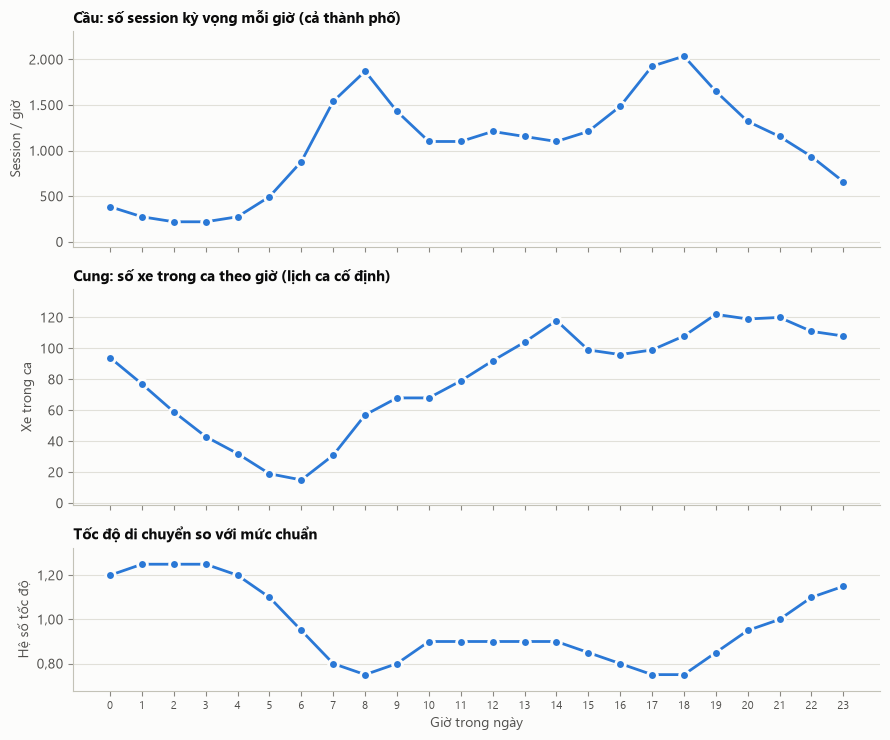

In [4]:
market = validation.market_by_hour(cfg)
fig = figures.market_figure(market)
save_figure(fig, "01_thi_truong_theo_gio")
plt.show()

## 2. Đường throughput và wild goose chase (A1)

A1 là kiểm thử quan trọng nhất: simulator phải **tự sinh ra** đoạn throughput giảm khi cầu vượt cung, chứ không được cài sẵn. Cách chạy (`docs/tests.md` A1): all_off, đội xe cố định luôn online, một giờ cao điểm ổn định (giờ 18), quét `demand_scale` 16 mức × 3 seed.

Đạt khi: (1) số chuyến hoàn thành mỗi giờ tăng rồi đạt đỉnh; (2) ở mức cầu lớn nhất còn ≤ 0,95 × đỉnh; (3) ở đoạn giảm slack < 0,45 (ngưỡng WGC của Castillo et al.); (4) ETA đón tăng đơn điệu, không bước nào > 3 phút.

In [5]:
throughput = pd.read_parquet(throughput_dir / "results" / "throughput_curve.parquet")
summary = validation.throughput_summary(throughput)
display(summary.round(3))
display(validation.a1_checks(summary))

,demand_scale,completed_per_h,mean_slack,mean_pickup_eta_min
0,0.25,80.306,36.263,2.059
1,0.50,161.389,17.116,2.071
2,0.75,241.278,10.697,2.124
3,1.00,317.667,7.400,2.234
4,1.25,393.097,5.370,2.349
5,1.50,467.472,3.959,2.504
6,1.75,534.736,2.952,2.720
7,2.00,598.861,2.189,2.951
8,2.25,656.792,1.589,3.257
9,2.50,708.264,1.135,3.583


,criterion,measure,passed
0,1. tăng rồi đạt đỉnh,"đỉnh 781,2 chuyến/giờ ở demand_scale 3,25",True
1,"2. mức cầu lớn nhất ≤ 0,95 × đỉnh","0,845 × đỉnh",True
2,"3. slack < 0,45 ở đoạn giảm","slack lớn nhất sau đỉnh 0,095",True
3,"4. ETA đón tăng đơn điệu, bước ≤ 3 phút","bước lớn nhất 1,871 phút",True


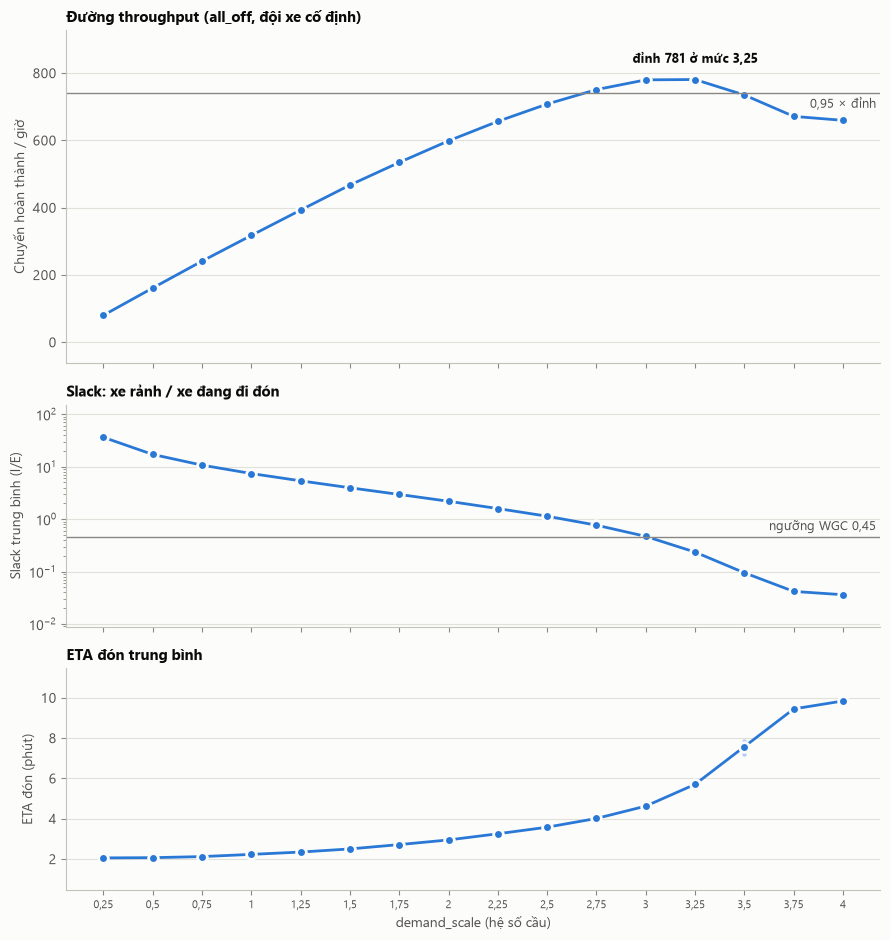

In [6]:
fig = throughput_figure(throughput)
save_figure(fig, "01_throughput")
plt.show()

**Đọc kết quả.** Đạt cả 4 điều kiện. Qua đỉnh, thêm cầu làm **giảm** số chuyến hoàn thành: slack (xe rảnh / xe đang đi đón) rơi xuống dưới 0,1, xe được gửi đi đón ở xa, thời gian đi đón tăng, rider hủy nhiều hơn. Đây là cơ chế làm voucher có thể gây hại khi cung căng: voucher thêm request đúng lúc hệ thống đã quá tải. Số liệu trùng với lần chạy ở gate P3 (log H3.2: đỉnh 781,2 ở mức 3,25).

## 3. Hiệu chỉnh (CAL)

Năm chỉ tiêu của `calibration_targets` trên all_off, 5 seed (`docs/tests.md` §4). Một session ở "ô dư cung" khi slack của **slot trước** cùng ô lớn hơn 1 (H-15). Mức tăng request khi có voucher tính từ hai xác suất ẩn trong **cùng bối cảnh** (`p_request_treat`, `p_request_control`, H-16), nên không lẫn hiệu ứng tắc nghẽn.

Hai dải tỷ lệ (ô, slot) căng và dư là **thiết kế kịch bản** ("có vùng căng thật"), không phải số đo từ dữ liệu thực (H-23). N(π_θ), θ\* và GTE không được dùng làm mục tiêu hiệu chỉnh.

In [7]:
cal_dirs = validation.full_run_dirs(gte_full_dir, "all_off")
cal = validation.calibration_metrics(cal_dirs)
display(validation.calibration_table(cal, dataclasses.asdict(cfg.calibration_targets)).round(4))

,target,value,lo,hi,in_range
0,p_request_no_voucher,0.1535,0.13,0.17,True
1,request_uplift_surplus,0.5059,0.35,0.70,True
2,mean_gross_fare_usd,19.0280,17.20,21.00,True
3,share_cellslots_slack_below_0_35,0.2791,0.10,0.35,True
4,share_cellslots_slack_above_1,0.6329,0.30,0.80,True


Cả 5 chỉ tiêu nằm trong khoảng. `tests/test_validation.py` kiểm rằng các số này, tính từ bảng đã lưu, bằng đúng số mà test chậm `test_cal_every_target_is_in_range` tính trong bộ nhớ trên cùng seed.

## 4. Các kiểm thử nghiệm thu còn lại

### A2. Số ngẫu nhiên chung (CRN)

- (a) Cùng chính sách, cùng seed chạy hai lần cho N, V giống hệt; (c) hai chính sách khác nhau gặp cùng tập session (cùng `session_id`, `rider_id`, ô đích, `u_book`). Hai ý này là test nhanh (`tests/test_acceptance.py::test_a2a_same_seed_same_run`, `test_a2c_policies_face_the_same_sessions`), pass trong `pytest -q`.
- (b) Với CRN, phương sai của hiệu N(all_on có B) − N(π_θ θ = 0,3) phải ≤ 0,5 × phương sai khi hai chính sách dùng seed độc lập. Dưới đây tính trên 30 seed của bảng T5.1 và sweep B7b; phương sai khi độc lập là Var(N₁) + Var(N₂) (T-37).

In [8]:
on_b = policy_runs(table_dir).query("label == 'all_on_B'").set_index("seed")["N_completed"]
sweep_ref = pd.read_parquet(sweep_ref_dir / "results" / "policy_results.parquet")
theta_03 = sweep_ref[sweep_ref["theta"] == 0.3].set_index("seed")["N_completed"]
pd.DataFrame([validation.crn_variance_ratio(on_b, theta_03),
              validation.crn_variance_ratio(on_b[on_b.index < 20], theta_03[theta_03.index < 20])],
             index=["30 seed", "20 seed (như tests.md)"]).round(3)

,n_seeds,mean_diff,var_crn,var_indep,ratio
30 seed,30,-206.467,1167.775,6820.506,0.171
20 seed (như tests.md),20,-197.000,1105.789,8183.768,0.135


Tỷ lệ khoảng 0,14–0,17, xa dưới ngưỡng 0,5: CRN giảm phương sai của hiệu giữa hai chính sách 6–7 lần. Đây là lý do mọi so sánh chính sách trong notebook 02 đều ghép cặp theo seed.

### A3. Dao động của π_θ

π_θ với θ = 0,35 (mặc định), 5 seed: số lần bật/tắt mỗi ô mỗi ngày. Trung vị > 12 thì chạy lại với hysteresis h = 0,1 và so sánh. Kiểm thử thông tin, không chặn mốc.

In [9]:
a3 = {}
for name, d in (("h = 0", a3_h0_dir), ("h = 0,1", a3_h01_dir)):
    r = pd.read_parquet(d / "results" / "policy_results.parquet")
    a3[name] = {**validation.per_seed_summary(r, "n_switches_per_cell_day"), "N_mean": r["N_completed"].mean()}
pd.DataFrame(a3).T.round(2)

,median,min,max,n,N_mean
h = 0,25.62,24.57,26.59,5.0,3884.6
"h = 0,1",25.03,23.65,25.86,5.0,3883.0


Trung vị khoảng 25 lần/ô/ngày, cao hơn mức 12. Hysteresis h = 0,1 chỉ giảm nhẹ và không đổi N. Lý do: ŝ dao động quanh θ ở nhiều ô vào giờ bình thường. Dao động này không làm hỏng kết quả đánh giá (N được đo trực tiếp), nhưng nếu đưa ra vận hành thì cần làm mượt (h lớn hơn, hoặc quyết định theo giờ thay vì theo slot); ghi vào hạn chế.

### A4. Tính đơn điệu

Hiệu ứng của voucher lên tỷ lệ hoàn thành mỗi session, theo tứ phân vị của slack slot trước (`slack_lag_slot`), trên switchback cụm 7 ô, bỏ burn-in. Đếm số lần đổi dấu. Hàm của Hoàng (`analysis/estimate.py`, H4.2).

In [10]:
frame = experiment_frame(b7a["switchback_c7_28d"])
a4 = effect_by_bin(frame, "cell_lag", quantiles=4)
display(a4.round(4))
print("số lần đổi dấu:", sign_changes(a4["effect"]))

,bin,n_off,n_on,rate_off,rate_on,effect,ci_lo,ci_hi,share_on
0,"[0, 0.125)",57140,75956,0.0865,0.1366,0.0500,0.0454,0.0547,0.5707
1,"[0.125, 1.28571)",56746,78922,0.1208,0.1853,0.0645,0.0599,0.0691,0.5817
2,"[1.28571, 7)",70282,63706,0.1471,0.2223,0.0751,0.0701,0.0800,0.4755
3,"[7, inf)",87186,48803,0.1539,0.2352,0.0813,0.0763,0.0865,0.3589


số lần đổi dấu: 0


Không đổi dấu: hiệu ứng dương và tăng dần theo slack. Cột `share_on` lệch khỏi 50% ở hai nhóm cuối cho thấy `slack_lag_slot` đã bị chính nhánh bật/tắt của block tác động (biến điều tiết không cân bằng giữa hai nhánh); notebook 04 dùng slack ngay trước block để tránh điều này.

### A5. Thời gian chạy

`--mode evaluate`, `default.yaml`, 1 ngày, log tối thiểu, 1 tiến trình: trung vị ≤ 30 giây. Thời gian đo là của engine cho một ngày mô phỏng (không tính các lượt pilot tìm B và κ).

In [11]:
r = pd.read_parquet(a5_dir / "results" / "policy_results.parquet")
pd.DataFrame([{**validation.per_seed_summary(r, "runtime_s"), "limit_s": cfg.performance.max_seconds_per_sim_day}]).round(2)

,median,min,max,n,limit_s
0,5.75,5.73,6.7,3,30.0


## 5. Các bộ dữ liệu giao cho phân tích

- **B7a** (T4.1): dữ liệu 28 ngày cho ước lượng: chính sách cũ có gây nhiễu (`legacy_28d`, có lát explore 5% ngẫu nhiên hóa), A/B theo rider, switchback cụm 1/7/toàn hệ; cộng `gte` (all_on và all_off không ngân sách, 10 seed) và `calibrate_budget` (mức B).
- **B7b** (T4.3, bản H-21): sweep θ tham chiếu 16 θ × 30 seed và bốn sweep độ nhạy (B × 1/3, B × 2, voucher 30%, cầu × 1,5).

Bảng dưới là tóm tắt của `analysis.check_dataset` cho từng thư mục; cột `problems` rỗng nghĩa là đạt mọi kiểm tra (schema, không cột ẩn trong `observed/`, `config_hash` khớp, không order bị cắt).

In [12]:
datasets = validation.datasets_table(dataset_dirs)
cols = ["name", "mode", "policy", "design", "n_runs", "seeds", "days", "budget_B_usd", "N_mean", "spent_mean",
        "size_mb", "config_hash", "problems"]
datasets[[c for c in cols if c in datasets.columns]].round(1)

,name,mode,policy,design,n_runs,seeds,days,budget_B_usd,N_mean,spent_mean,size_mb,config_hash,problems
0,calibrate_budget,calibrate_budget,all_on,,1,9000,1.0,5545.8,NaN,NaN,0.0,298741e99142,
1,gte,gte,all_off/all_on,,20,0–9,1.0,NaN,4046.0,9315.2,0.0,298741e99142,
2,legacy_28d,generate,legacy,,1,0,28.0,5545.8,108410.0,152342.5,56.4,56fe64fb463b,
3,rider_ab_28d,generate,experiment,"rider_ab, p_on 0.5, block 60 phút",1,0,28.0,NaN,115116.0,279152.0,55.3,1cd6d61dc7d7,
4,switchback_c1_28d,generate,experiment,"cluster_switchback, cụm 1, p_on 0.5, block 60 ...",1,0,28.0,NaN,114932.0,276314.9,55.9,0a500f78bb05,
5,switchback_c7_28d,generate,experiment,"cluster_switchback, cụm 7, p_on 0.5, block 60 ...",1,0,28.0,NaN,114040.0,268964.4,55.6,bf5ccce8c655,
6,switchback_all_28d,generate,experiment,"cluster_switchback, cụm all, p_on 0.5, block 6...",1,0,28.0,NaN,113990.0,265403.5,54.8,60fa66719536,
7,sweep_theta_ref,sweep_theta,threshold,,480,0–29,1.0,5545.8,3872.1,5312.6,0.1,19f46649271e,
8,sens_fraction_0p1,sweep_theta,threshold,,160,0–9,1.0,1848.6,3595.1,1838.0,0.1,d7d4dc44722f,
9,sens_fraction_0p6,sweep_theta,threshold,,160,0–9,1.0,11091.6,4179.1,9727.4,0.1,0859f9a2339c,


## Tóm tắt

| Kiểm thử | Kết quả | Ghi chú |
|---|---|---|
| A1 throughput | đạt 4/4 | đoạn giảm có slack < 0,1, WGC tự xuất hiện |
| A2 CRN | (a), (c) đạt (test nhanh); (b) tỷ lệ phương sai ≈ 0,15 | ngưỡng 0,5 |
| A3 dao động | trung vị ≈ 25 lần/ô/ngày | thông tin; h = 0,1 giảm ít |
| A4 đơn điệu | 0 lần đổi dấu | thông tin |
| A5 thời gian | trung vị ≈ 6 giây / ngày mô phỏng | ngưỡng 30 giây |
| CAL | 5/5 trong khoảng | hai dải căng/dư là thiết kế kịch bản (H-23) |

Gate P3 đạt; gate P6 đạt trên lưới θ tham chiếu theo T-31 (chờ mentor xác nhận). Các giới hạn của simulator (một thế giới, cầu không có trí nhớ, lịch ca cố định) ở báo cáo phương pháp bản 1, §10.